# VNINDEX × Vietnam Government Bond Yields — Correlation Benchmark

How much does the VN-Index move with government bond yields (**1Y / 5Y / 10Y**),
and does either side *lead* the other?

## What this measures

| | |
|--|--|
| **No lag** | contemporaneous correlation — same-day index return vs same-day yield change |
| **With lag** | cross-correlation over ±60 trading days, to see whether yields lead the index or the index leads yields |
| **Predictive** | does a *past* yield move forecast *forward* index returns (1/5/10/21 days)? |

## Method notes (read before trusting a number)

1. **Levels are differenced.** VNINDEX and yields are both non-stationary; the
   correlation of two trending levels is [spurious](https://en.wikipedia.org/wiki/Spurious_relationship)
   — it measures shared drift, not co-movement. The headline numbers use
   **log returns** for the index and **daily changes in percentage points** for
   yields. Level correlation is reported once, flagged, and then dropped. Section 2
   runs an ADF test to show why.
2. **Lag sign convention** — everywhere in this notebook:
   `corr(index_return[t], yield_change[t − lag])`
   * **lag > 0 → the yield move came first** (yields lead the index)
   * **lag < 0 → the index moved first** (index leads yields)
3. **Overlapping forward returns inflate t-stats.** The predictive section uses
   Newey–West (HAC) standard errors, not raw OLS ones.
4. **Multiple comparisons.** Scanning 121 lags × 3 tenors will *always* surface
   something that looks significant. The ±1.96/√N band on the cross-correlation
   plot is a per-lag threshold, not a family-wise one — treat a lone spike just
   outside it as noise unless it is part of a broad, contiguous hump.

In [34]:
import warnings
warnings.filterwarnings('ignore')

import os, sys, pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.colors import LinearSegmentedColormap
from scipy import stats

ROOT = pathlib.Path('..').resolve()
sys.path.insert(0, str(ROOT))
# Numba disk cache from the FastAPI runtime stores module paths as `app.*`.
sys.path.insert(0, str(ROOT / 'backend'))
import backend.app
import backend.app.services
sys.modules.setdefault('app', backend.app)
sys.modules.setdefault('app.services', backend.app.services)

plt.style.use('dark_background')

# ── chart system ────────────────────────────────────────────────────────────
# Categorical hues in FIXED slot order (never cycled), stepped for the dark
# surface; validated for colour-blind separation on #1a1a19.
SURFACE   = '#1a1a19'
INK       = '#c3c2b7'          # secondary ink — labels, the reference series
GRID      = '#3a3a37'
TENORS    = ['VIETNAM_1Y', 'VIETNAM_5Y', 'VIETNAM_10Y']
COLORS    = {'VIETNAM_1Y': '#3987e5',   # slot 1  blue
             'VIETNAM_5Y': '#d95926',   # slot 2  orange
             'VIETNAM_10Y': '#199e70'}  # slot 3  aqua
BENCH_C   = INK
LABEL     = {'VIETNAM_1Y': '1Y', 'VIETNAM_5Y': '5Y', 'VIETNAM_10Y': '10Y'}

# Correlation is polarity data: two hues + a NEUTRAL GREY midpoint, never a rainbow.
CORR_CMAP = LinearSegmentedColormap.from_list(
    'corr_div', ['#3987e5', '#6f8fa8', '#4a4a47', '#a8734a', '#d95926'], N=256)

def style_axes(ax, ylabel=None, title=None):
    ax.grid(True, color=GRID, alpha=0.35, linewidth=0.6)
    ax.set_axisbelow(True)
    for side in ('top', 'right'):
        ax.spines[side].set_visible(False)
    for side in ('left', 'bottom'):
        ax.spines[side].set_color(GRID)
    ax.tick_params(colors=INK, labelsize=9)
    if ylabel:
        ax.set_ylabel(ylabel, color=INK, fontsize=9)
    if title:
        ax.set_title(title, color='white', fontsize=11, loc='left', pad=8)
    return ax

def end_labels(ax, values: dict, fmt='{:+.2f}', x=None, min_gap_frac=0.055):
    '''Right-edge labels for each series, nudged apart so they never overlap.'''
    span = ax.get_ylim()[1] - ax.get_ylim()[0]
    gap = span * min_gap_frac
    placed = []
    for key, y in sorted(values.items(), key=lambda kv: -kv[1]):
        y_lab = y
        for prev in placed:
            if abs(y_lab - prev) < gap:
                y_lab = prev - gap
        placed.append(y_lab)
        ax.annotate(f'{LABEL.get(key, key)}  {fmt.format(y)}',
                    xy=(x if x is not None else ax.get_xlim()[1], y_lab),
                    xytext=(6, 0), textcoords='offset points',
                    color=COLORS.get(key, BENCH_C), fontsize=9, va='center',
                    annotation_clip=False)


BENCHMARK  = 'VNINDEX'
DATA_START = '2016-01-01'   # overlap of the OHLC cache and the yield history
MAX_LAG    = 60             # trading days scanned each side
ROLL_WIN   = 126            # ~6 months, for the rolling-correlation panel

print('imports ok')

imports ok


## 1. Load Data

**VNINDEX** comes from the standard notebook loader (`load_stocks`, HDF5 cache →
DeltaLake), exactly as in `backtest_010`.

**Yields** need their own loader. `load_stocks` filters to
`models/watchlist.csv`, which lists VNINDEX but not the `VIETNAM_*Y`
pseudo-symbols, so they would be dropped even once the crawl has populated the
table. `load_yields` therefore tries, in order:

1. the **`stocks` Delta table** — where `crawl_ohlc_data.py` now writes them as
   pseudo-symbols (`sync_ticker_delta_table_pipeline`, Task 1b);
2. the **live wichart endpoint** (`fetchMacroFrame`) — always available, and the
   only source until that flow has run.

In [35]:
from backend.app.services.data_loader import load_stocks

df_raw = load_stocks(exclude=[], refresh=False)
df_raw = df_raw.loc[DATA_START:]

close  = df_raw['close']
volume = df_raw['volume']

assert BENCHMARK in close.columns, f'{BENCHMARK} missing from the panel'
bm_close = close[BENCHMARK].dropna()

print(f'{BENCHMARK}: {len(bm_close)} bars  |  '
      f'{bm_close.index[0].date()} -> {bm_close.index[-1].date()}')

Loading from HDF5 cache: stocks_data_latest.h5
Shape: (2538, 1000)  |  2016-08-22 → 2026-08-19
VNINDEX: 2538 bars  |  2016-08-22 -> 2026-08-19


In [36]:
MIN_YIELD_ROWS = 500   # fewer than this in Delta = a partial backfill, not history


def load_yields(source: str = 'auto', years: int = 15,
                min_rows: int = MIN_YIELD_ROWS) -> pd.DataFrame:
    '''Bond-yield levels (percent) as a bars x tenor frame.

    source
      'auto'  prefer the Delta table, fall back to the API when Delta holds less
              than `min_rows` of history. That fallback is the normal case at
              first: the ticker flow appends only the trailing ~20 days on an
              incremental run, so the Delta copy stays a few dozen rows deep
              until it has been run once with `full_refresh=True`.
      'delta' Delta only (raises if unavailable)
      'api'   the live wichart endpoint only — full history back to 2008
    '''
    delta_wide = None
    if source in ('auto', 'delta'):
        try:
            from deltalake import DeltaTable
            from backend.app.services.data_loader import _STORAGE_OPTIONS

            start = pd.Timestamp.now() - pd.DateOffset(years=years)
            dt = DeltaTable('s3://delta-table-storage/stocks',
                            storage_options=_STORAGE_OPTIONS)
            raw = dt.to_pandas(
                filters=[('date', '>=', start), ('symbol', 'in', TENORS)],
                columns=['symbol', 'date', 'close'],
            )
            if raw.empty:
                raise ValueError('no VIETNAM_*Y rows in the stocks table yet')
            delta_wide = (raw.drop_duplicates(subset=['date', 'symbol'], keep='last')
                             .pivot(index='date', columns='symbol', values='close')
                             .sort_index())
            print(f'DeltaLake has {delta_wide.shape[1]} tenors x {len(delta_wide)} rows '
                  f'({delta_wide.index[0].date()} -> {delta_wide.index[-1].date()})')
        except Exception as exc:
            print(f'Delta yield load unavailable ({exc})')
            if source == 'delta':
                raise

    if delta_wide is not None and (source == 'delta' or len(delta_wide) >= min_rows):
        return delta_wide

    if delta_wide is not None:
        print(f'  -> only {len(delta_wide)} rows (< {min_rows}); using the API for full '
              f'history. Backfill Delta with '
              f'sync_ticker_delta_table_pipeline(full_refresh=True).')

    from backend.app.utils.wichart import fetchMacroFrame

    macro = fetchMacroFrame(log=None)
    macro['symbol'] = macro['dim_name'].str.upper()
    wide = (macro[macro['symbol'].isin(TENORS)]
            .pivot(index='date', columns='symbol', values='value')
            .sort_index())
    print(f'Yields from the wichart API: {wide.shape[1]} tenors x {len(wide)} rows '
          f'({wide.index[0].date()} -> {wide.index[-1].date()})')
    return wide


yields_raw = load_yields('auto')
yields_raw.tail(3)

DeltaLake has 3 tenors x 3780 rows (2011-08-22 -> 2026-08-19)


symbol,VIETNAM_10Y,VIETNAM_1Y,VIETNAM_5Y
date,,,
2026-08-17,4.569,3.661,4.348
2026-08-18,4.568,3.661,4.345
2026-08-19,4.563,3.661,4.355


In [37]:
# Align on VNINDEX trading days. Yields publish most weekdays but not all, so
# carry the last print forward a few days — never backwards (that would be a
# look-ahead).
px = pd.DataFrame({BENCHMARK: bm_close})
for t in TENORS:
    px[t] = yields_raw[t].reindex(bm_close.index).ffill(limit=5)

px = px.loc[DATA_START:].dropna()

cover = pd.DataFrame({
    'first': px.apply(lambda s: s.first_valid_index().date()),
    'last':  px.apply(lambda s: s.last_valid_index().date()),
    'obs':   px.notna().sum(),
    'mean':  px.mean().round(3),
    'min':   px.min().round(3),
    'max':   px.max().round(3),
})
print(f'Aligned panel: {len(px)} common trading days  |  '
      f'{px.index[0].date()} -> {px.index[-1].date()}')

# Every statistic below is meaningless on a short overlap, and a ±60-day lag scan
# needs room to move, so clamp the scan and say so rather than reporting noise.
MAX_LAG = min(MAX_LAG, max(1, len(px) // 8))
if len(px) < 250:
    print(f'\n!! Only {len(px)} overlapping days — treat every number below as '
          f'indicative at best. Load the yields with source="api" for full history.')
print(f'Lag scan: ±{MAX_LAG} days  |  rolling window: {ROLL_WIN} days\n')
cover

Aligned panel: 2538 common trading days  |  2016-08-22 -> 2026-08-19
Lag scan: ±60 days  |  rolling window: 126 days



,first,last,obs,mean,min,max
VNINDEX,2016-08-22,2026-08-19,2538,1149.426,651.310,1927.940
VIETNAM_1Y,2016-08-22,2026-08-19,2538,2.478,0.267,5.034
VIETNAM_5Y,2016-08-22,2026-08-19,2538,3.029,0.813,5.889
VIETNAM_10Y,2016-08-22,2026-08-19,2538,3.803,1.983,6.880


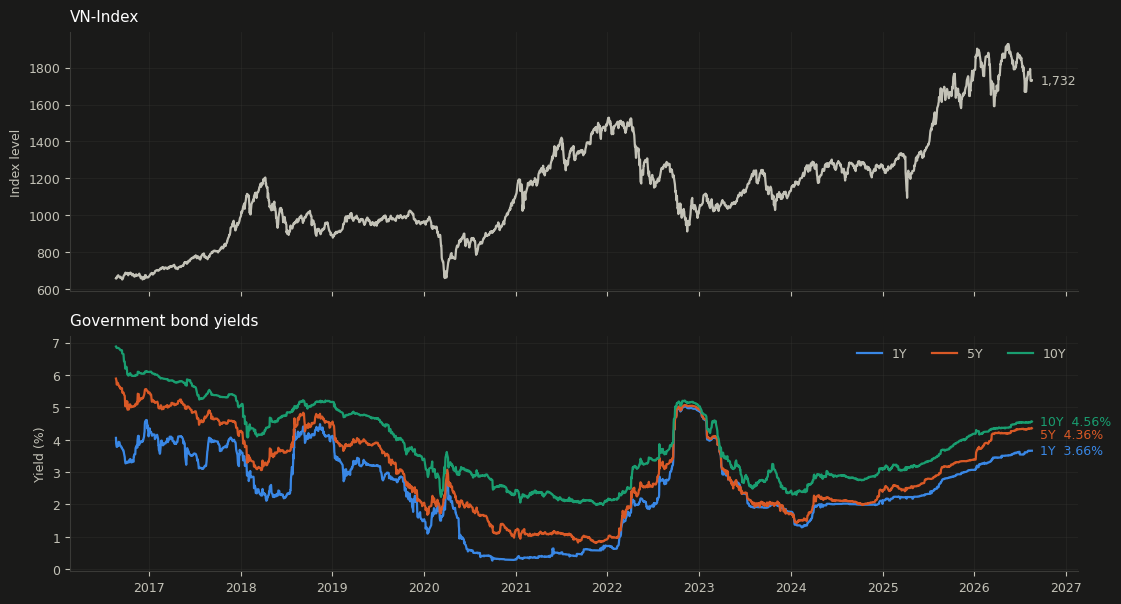

In [38]:
# Two stacked panels sharing the x-axis — deliberately NOT a dual-axis chart:
# an index level and a percent yield share no scale, and twin axes let the
# reader "see" whatever correlation the arbitrary scaling implies.
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 7), sharex=True,
                               gridspec_kw={'height_ratios': [1.1, 1]})
fig.patch.set_facecolor(SURFACE)
for ax in (ax1, ax2):
    ax.set_facecolor(SURFACE)

ax1.plot(px.index, px[BENCHMARK], color=BENCH_C, linewidth=1.6)
style_axes(ax1, 'Index level', 'VN-Index')
ax1.annotate(f'{px[BENCHMARK].iloc[-1]:,.0f}',
             xy=(px.index[-1], px[BENCHMARK].iloc[-1]),
             xytext=(6, 0), textcoords='offset points',
             color=BENCH_C, fontsize=9, va='center')

for t in TENORS:
    ax2.plot(px.index, px[t], color=COLORS[t], linewidth=1.6, label=LABEL[t])
style_axes(ax2, 'Yield (%)', 'Government bond yields')
end_labels(ax2, {t: px[t].iloc[-1] for t in TENORS}, fmt='{:.2f}%', x=px.index[-1])
ax2.legend(frameon=False, labelcolor=INK, fontsize=9, ncol=3, loc='upper right')
ax2.xaxis.set_major_locator(mdates.YearLocator())
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

fig.subplots_adjust(right=0.90, hspace=0.18)
plt.show()

## 2. Levels vs Changes — why the differencing matters

Both series wander. An Augmented Dickey–Fuller test on the levels should fail to
reject a unit root (**p > 0.05 ⇒ non-stationary**), while the differenced series
should reject it decisively. Correlating the levels of two non-stationary series
is the classic spurious-regression trap, so everything after this section works
on changes.

* **VNINDEX** → daily **log return**
* **Yields** → daily **change in percentage points** (a move from 4.50% to 4.55%
  is `+0.05`, i.e. +5 bp)

In [39]:
from statsmodels.tsa.stattools import adfuller

ret = pd.DataFrame({BENCHMARK: np.log(px[BENCHMARK]).diff()})
for t in TENORS:
    ret[t] = px[t].diff()
ret = ret.dropna()

rows = []
for col in px.columns:
    lvl = adfuller(px[col].dropna(), autolag='AIC')
    chg = adfuller(ret[col].dropna(), autolag='AIC')
    rows.append({
        'series': col,
        'ADF p (level)':  round(lvl[1], 4),
        'level verdict':  'non-stationary' if lvl[1] > 0.05 else 'stationary',
        'ADF p (change)': round(chg[1], 6),
        'change verdict': 'stationary' if chg[1] <= 0.05 else 'non-stationary',
    })
adf_tbl = pd.DataFrame(rows).set_index('series')
print(f'Differenced sample: {len(ret)} observations\n')
adf_tbl

Differenced sample: 2537 observations



,ADF p (level),level verdict,ADF p (change),change verdict
series,,,,
VNINDEX,0.7351,non-stationary,0.0,stationary
VIETNAM_1Y,0.3578,non-stationary,0.0,stationary
VIETNAM_5Y,0.3500,non-stationary,0.0,stationary
VIETNAM_10Y,0.1194,non-stationary,0.0,stationary


## 3. Contemporaneous Correlation (no lag)

Same-day pairing. Pearson answers "do they move together linearly"; Spearman
answers "do they move together at all" and is far less sensitive to the fat tails
that dominate both series.

`sig` is the two-sided p-value; `|r| > 1.96/√N` marks the conventional threshold
for a single test at N observations.

In [40]:
def corr_table(frame: pd.DataFrame, method: str = 'pearson') -> pd.DataFrame:
    '''Correlation of each tenor against the benchmark, with p-value and CI.'''
    n = len(frame)
    crit = 1.96 / np.sqrt(n)
    out = []
    for t in TENORS:
        a, b = frame[BENCHMARK], frame[t]
        ok = a.notna() & b.notna()
        fn = stats.pearsonr if method == 'pearson' else stats.spearmanr
        r, p = fn(a[ok], b[ok])
        out.append({'tenor': LABEL[t], 'r': round(r, 4), 'p': f'{p:.2e}',
                    'signif': '✓' if abs(r) > crit else '·', 'n': int(ok.sum())})
    tbl = pd.DataFrame(out).set_index('tenor')
    tbl.attrs['crit'] = crit
    return tbl

lvl_p = corr_table(px, 'pearson')
chg_p = corr_table(ret, 'pearson')
chg_s = corr_table(ret, 'spearman')

print(f'|r| threshold at N={len(ret)}: {1.96 / np.sqrt(len(ret)):.4f}\n')
print('LEVELS — Pearson  (spurious: both series are non-stationary, see §2)')
print(lvl_p.to_string(), '\n')
print('CHANGES — Pearson  (the headline number)')
print(chg_p.to_string(), '\n')
print('CHANGES — Spearman (rank, tail-robust)')
print(chg_s.to_string())

|r| threshold at N=2537: 0.0389

LEVELS — Pearson  (spurious: both series are non-stationary, see §2)
            r          p signif     n
tenor                                
1Y    -0.1742   9.58e-19      ✓  2538
5Y    -0.2900   2.21e-50      ✓  2538
10Y   -0.4095  3.10e-103      ✓  2538 

CHANGES — Pearson  (the headline number)
            r         p signif     n
tenor                               
1Y    -0.0652  1.03e-03      ✓  2537
5Y    -0.0725  2.56e-04      ✓  2537
10Y   -0.0809  4.47e-05      ✓  2537 

CHANGES — Spearman (rank, tail-robust)
            r         p signif     n
tenor                               
1Y    -0.0658  9.17e-04      ✓  2537
5Y    -0.0575  3.77e-03      ✓  2537
10Y   -0.0326  1.00e-01      ·  2537


In [41]:
# Same-day correlation across horizons: daily noise can hide a relationship that
# only shows up once you aggregate. Non-overlapping resamples, so each row is an
# independent sample rather than a smoothed version of the one above it.
HORIZONS = {'daily': 1, 'weekly': 5, 'monthly': 21, 'quarterly': 63}

rows = []
for name, k in HORIZONS.items():
    idx = ret.index[::k]
    agg = pd.DataFrame({
        BENCHMARK: np.log(px[BENCHMARK]).reindex(idx).diff(),
        **{t: px[t].reindex(idx).diff() for t in TENORS},
    }).dropna()
    if len(agg) < 3:
        print(f'skipping {name}: only {len(agg)} non-overlapping observations')
        continue
    rec = {'horizon': name, 'n': len(agg)}
    for t in TENORS:
        r, p = stats.pearsonr(agg[BENCHMARK], agg[t])
        rec[LABEL[t]] = round(r, 3)
        rec[f'{LABEL[t]} p'] = f'{p:.3f}'
    rows.append(rec)

horizon_tbl = pd.DataFrame(rows).set_index('horizon')
horizon_tbl

,n,1Y,1Y p,5Y,5Y p,10Y,10Y p
horizon,,,,,,,
daily,2536,-0.065,0.001,-0.072,0.000,-0.081,0.000
weekly,507,-0.180,0.000,-0.247,0.000,-0.265,0.000
monthly,120,-0.300,0.001,-0.383,0.000,-0.395,0.000
quarterly,40,-0.249,0.121,-0.324,0.041,-0.317,0.046


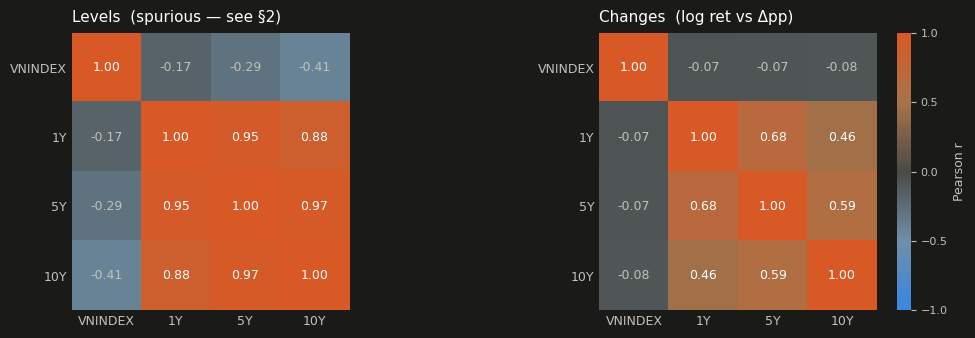

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(13, 3.6))
fig.patch.set_facecolor(SURFACE)

for ax, (frame, name) in zip(axes, [(px, 'Levels  (spurious — see §2)'),
                                    (ret, 'Changes  (log ret vs Δpp)')]):
    cols = [BENCHMARK] + TENORS
    m = frame[cols].corr()
    im = ax.imshow(m.values, cmap=CORR_CMAP, vmin=-1, vmax=1)
    names = ['VNINDEX'] + [LABEL[t] for t in TENORS]
    ax.set_xticks(range(len(cols)), names, color=INK, fontsize=9)
    ax.set_yticks(range(len(cols)), names, color=INK, fontsize=9)
    for i in range(len(cols)):
        for j in range(len(cols)):
            v = m.values[i, j]
            ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=9,
                    color='white' if abs(v) > 0.45 else INK)
    ax.set_title(name, color='white', fontsize=11, loc='left', pad=8)
    ax.set_facecolor(SURFACE)
    for s in ax.spines.values():
        s.set_visible(False)
    ax.tick_params(length=0)

cb = fig.colorbar(im, ax=axes, fraction=0.02, pad=0.02, ticks=[-1, -0.5, 0, 0.5, 1])
cb.ax.tick_params(colors=INK, labelsize=8)
cb.outline.set_visible(False)
cb.set_label('Pearson r', color=INK, fontsize=9)
plt.show()

## 4. Lead–Lag Cross-Correlation (±60 trading days)

`corr(index_return[t], yield_change[t − lag])` — so **lag > 0 means the yield
moved first**. A relationship worth acting on shows up as a *broad hump* on one
side of zero, not a single spike: adjacent lags share most of their data, so a
real effect smears across neighbours.

The shaded band is ±1.96/√N, the single-test threshold.

In [43]:
def cross_corr(target: pd.Series, driver: pd.Series,
               max_lag: int = MAX_LAG, method: str = 'pearson') -> pd.Series:
    '''corr(target[t], driver[t - lag]) for lag in [-max_lag, +max_lag].

    lag > 0 -> driver leads target;  lag < 0 -> target leads driver.
    '''
    lags = range(-max_lag, max_lag + 1)
    return pd.Series({L: target.corr(driver.shift(L), method=method) for L in lags},
                     name=driver.name).rename_axis('lag')

# Daily changes, and the same scan on weekly changes. Daily cross-correlations
# are dominated by noise (every lag shares ~99% of its sample with its
# neighbours); the weekly scan is where a lead, if there is one, shows up.
MAX_LAG_W = 12   # weeks

wk = px.resample('W-FRI').last()
ret_w = pd.DataFrame({BENCHMARK: np.log(wk[BENCHMARK]).diff(),
                      **{t: wk[t].diff() for t in TENORS}}).dropna()

xc   = pd.DataFrame({t: cross_corr(ret[BENCHMARK],   ret[t],   MAX_LAG)   for t in TENORS})
xc_w = pd.DataFrame({t: cross_corr(ret_w[BENCHMARK], ret_w[t], MAX_LAG_W) for t in TENORS})

rows = []
for freq, tbl, n, unit in [('daily', xc, len(ret), 'days'),
                           ('weekly', xc_w, len(ret_w), 'weeks')]:
    band_f = 1.96 / np.sqrt(n)
    for t in TENORS:
        s_ = tbl[t]
        peak = s_.abs().idxmax()
        rows.append({
            'freq': freq, 'tenor': LABEL[t], 'n': n,
            'r @ lag 0': round(s_.loc[0], 4),
            f'peak lag': f'{int(peak):+d} {unit}',
            'peak r': round(s_.loc[peak], 4),
            'who leads': ('yields lead' if peak > 0 else
                          'index leads' if peak < 0 else 'same period'),
            'peak beats band': '✓' if abs(s_.loc[peak]) > band_f else '·',
            'lags beating band': int((tbl[t].abs() > band_f).sum()),
        })
best_tbl = pd.DataFrame(rows).set_index(['freq', 'tenor'])
print(f'weekly sample: {len(ret_w)} weeks  |  daily: {len(ret)} days\n')
best_tbl

weekly sample: 517 weeks  |  daily: 2537 days



n  r @ lag 0  peak lag  peak r    who leads peak beats band  \
freq   tenor                                                                   
daily  1Y     2537    -0.0652   +0 days -0.0652  same period               ✓   
       5Y     2537    -0.0725   +0 days -0.0725  same period               ✓   
       10Y    2537    -0.0809   -1 days -0.0904  index leads               ✓   
weekly 1Y      517    -0.1373  +0 weeks -0.1373  same period               ✓   
       5Y      517    -0.2139  +0 weeks -0.2139  same period               ✓   
       10Y     517    -0.2459  +0 weeks -0.2459  same period               ✓   

              lags beating band  
freq   tenor                     
daily  1Y                    17  
       5Y                    17  
       10Y                   15  
weekly 1Y                     3  
       5Y                     3  
       10Y                    4

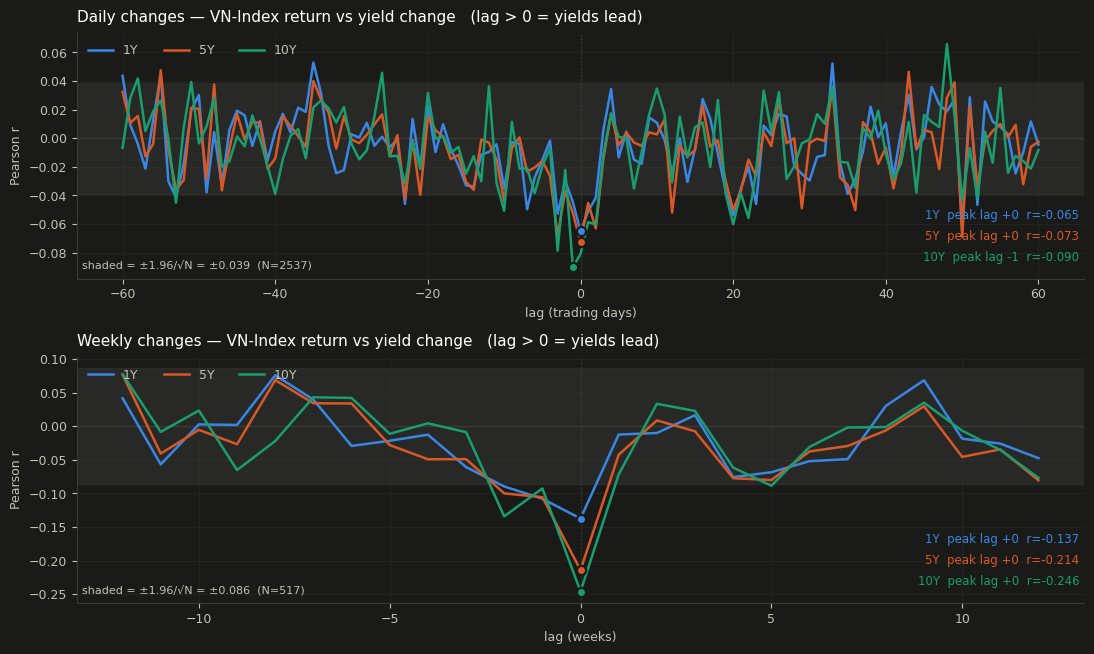

In [44]:
fig, axes = plt.subplots(2, 1, figsize=(13, 7.4))
fig.patch.set_facecolor(SURFACE)

panels = [(axes[0], xc, len(ret), 'Daily changes', 'lag (trading days)'),
          (axes[1], xc_w, len(ret_w), 'Weekly changes', 'lag (weeks)')]

for ax, tbl, n, name, xlabel in panels:
    ax.set_facecolor(SURFACE)
    band_f = 1.96 / np.sqrt(n)
    ax.axhspan(-band_f, band_f, color=GRID, alpha=0.45, zorder=0)
    ax.axhline(0, color=GRID, linewidth=1)
    ax.axvline(0, color=GRID, linewidth=1, linestyle=':')

    for t in TENORS:
        ax.plot(tbl.index, tbl[t], color=COLORS[t], linewidth=1.8, label=LABEL[t])
        peak = tbl[t].abs().idxmax()
        ax.scatter([peak], [tbl[t].loc[peak]], s=44, color=COLORS[t],
                   edgecolor=SURFACE, linewidth=1.6, zorder=3)

    style_axes(ax, 'Pearson r',
               f'{name} — VN-Index return vs yield change   (lag > 0 = yields lead)')
    ax.set_xlabel(xlabel, color=INK, fontsize=9)
    ax.legend(frameon=False, labelcolor=INK, fontsize=9, ncol=3, loc='upper left')

    # Peak read-out in the corner rather than on the curve: at daily frequency the
    # 5Y and 10Y peaks sit a day apart and their labels would overlap.
    lines = [f'{LABEL[t]}  peak lag {int(tbl[t].abs().idxmax()):+d}  '
             f'r={tbl[t].loc[tbl[t].abs().idxmax()]:+.3f}' for t in TENORS]
    for i, (t, line) in enumerate(zip(TENORS, lines)):
        ax.text(0.995, 0.06 + 0.085 * (len(TENORS) - 1 - i), line,
                transform=ax.transAxes, ha='right', va='bottom',
                color=COLORS[t], fontsize=8.5)
    ax.text(0.005, 0.04, f'shaded = ±1.96/√N = ±{band_f:.3f}  (N={n})',
            transform=ax.transAxes, color=INK, fontsize=8)

fig.subplots_adjust(hspace=0.32)
plt.show()

## 5. Predictive Benchmark — does a past yield move forecast the index?

Correlation at a lag is not a forecast. Here the question is put directly: regress
the **forward** index return over `h` days on the **trailing** `k`-day yield
change, and read the slope's significance.

Forward windows overlap, which makes plain OLS standard errors far too small, so
`t (HAC)` uses Newey–West with `maxlags = h`. Rule of thumb: **|t| > 2** is
suggestive, and only when it holds across neighbouring `(k, h)` cells.

In [45]:
import statsmodels.api as sm

PRED_K = [1, 5, 21]          # trailing yield-change windows
FWD_H  = [1, 5, 10, 21]      # forward index-return horizons

log_px = np.log(px[BENCHMARK])
rows = []
for t in TENORS:
    for k in PRED_K:
        drv = px[t].diff(k)
        for h in FWD_H:
            fwd = log_px.shift(-h) - log_px
            d = pd.concat([fwd.rename('y'), drv.rename('x')], axis=1).dropna()
            if len(d) < 30:
                continue
            r, _ = stats.pearsonr(d['x'], d['y'])
            fit = sm.OLS(d['y'], sm.add_constant(d['x'])).fit(
                cov_type='HAC', cov_kwds={'maxlags': h})
            rows.append({
                'tenor': LABEL[t], 'Δyield window (k)': k, 'fwd horizon (h)': h,
                'r': round(r, 4),
                'beta (ret per 1pp)': round(fit.params.iloc[1], 4),
                't (HAC)': round(fit.tvalues.iloc[1], 2),
                'p (HAC)': round(fit.pvalues.iloc[1], 3),
                'n': len(d),
            })

pred = pd.DataFrame(rows)
pred['flag'] = np.where(pred['t (HAC)'].abs() > 2, '✓', '·')
for t in TENORS:
    print(f'\n{LABEL[t]}  — forward index return vs trailing yield change')
    print(pred[pred['tenor'] == LABEL[t]]
          .drop(columns='tenor').to_string(index=False))


1Y  — forward index return vs trailing yield change
 Δyield window (k)  fwd horizon (h)       r  beta (ret per 1pp)  t (HAC)  p (HAC)    n flag
                 1                1 -0.0513             -0.0107    -2.54    0.011 2536    ✓
                 1                5 -0.0276             -0.0138    -0.86    0.388 2532    ·
                 1               10 -0.0199             -0.0144    -0.50    0.615 2527    ·
                 1               21 -0.0455             -0.0475    -1.06    0.290 2516    ·
                 5                1 -0.0241             -0.0019    -1.00    0.316 2532    ·
                 5                5 -0.0141             -0.0027    -0.26    0.792 2528    ·
                 5               10 -0.0184             -0.0050    -0.26    0.793 2523    ·
                 5               21 -0.0789             -0.0312    -1.13    0.260 2512    ·
                21                1 -0.0339             -0.0011    -1.45    0.148 2516    ·
                21         

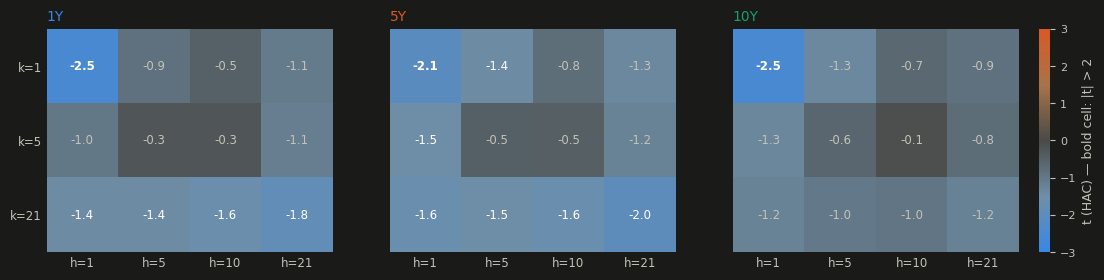

In [46]:
# Heatmap of HAC t-stats: polarity data, so the diverging map is centred on 0 and
# the scale is symmetric. |t| > 2 is the cell worth a second look.
fig, axes = plt.subplots(1, 3, figsize=(13, 2.9), sharey=True)
fig.patch.set_facecolor(SURFACE)
tmax = max(3.0, float(pred['t (HAC)'].abs().max()))

for ax, t in zip(axes, TENORS):
    grid = (pred[pred['tenor'] == LABEL[t]]
            .pivot(index='Δyield window (k)', columns='fwd horizon (h)', values='t (HAC)'))
    im = ax.imshow(grid.values, cmap=CORR_CMAP, vmin=-tmax, vmax=tmax, aspect='auto')
    ax.set_xticks(range(len(grid.columns)), [f'h={c}' for c in grid.columns],
                  color=INK, fontsize=8.5)
    ax.set_yticks(range(len(grid.index)), [f'k={i}' for i in grid.index],
                  color=INK, fontsize=8.5)
    for i in range(grid.shape[0]):
        for j in range(grid.shape[1]):
            v = grid.values[i, j]
            ax.text(j, i, f'{v:.1f}', ha='center', va='center', fontsize=8.5,
                    color='white' if abs(v) > tmax * 0.45 else INK,
                    fontweight='bold' if abs(v) > 2 else 'normal')
    ax.set_title(LABEL[t], color=COLORS[t], fontsize=10, loc='left', pad=6)
    ax.set_facecolor(SURFACE)
    for s in ax.spines.values():
        s.set_visible(False)
    ax.tick_params(length=0)

cb = fig.colorbar(im, ax=axes, fraction=0.015, pad=0.02)
cb.ax.tick_params(colors=INK, labelsize=8)
cb.outline.set_visible(False)
cb.set_label('t (HAC) — bold cell: |t| > 2', color=INK, fontsize=9)
plt.show()

## 6. Rolling Stability

A full-sample average hides regime changes. If the 6-month rolling correlation
flips sign every few quarters, the full-sample number is a description of the past
decade, not a usable prior.

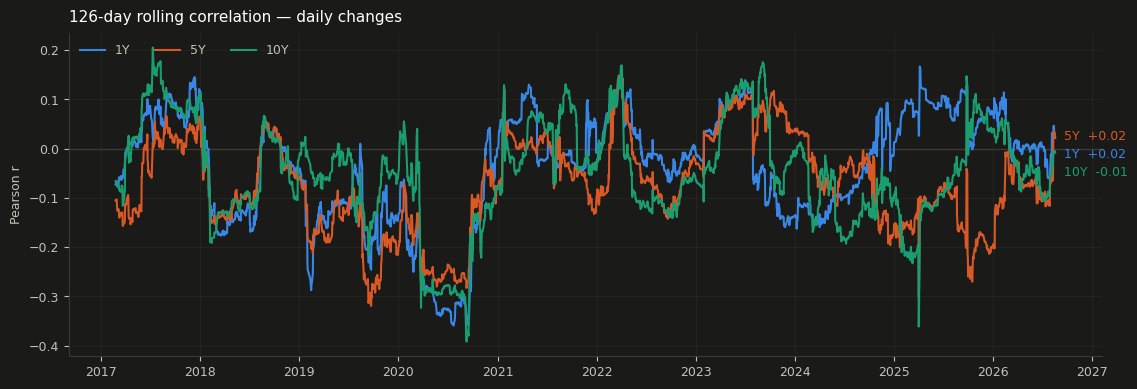

,mean,std,min,max,share > 0,latest
1Y,-0.034,0.111,-0.359,0.167,0.446,0.022
5Y,-0.074,0.096,-0.319,0.149,0.258,0.024
10Y,-0.049,0.104,-0.391,0.205,0.298,-0.008


In [47]:
win = min(ROLL_WIN, max(20, len(ret) // 4))
if win != ROLL_WIN:
    print(f'rolling window shortened to {win} days to fit a {len(ret)}-day sample')
roll = pd.DataFrame({t: ret[BENCHMARK].rolling(win).corr(ret[t]) for t in TENORS}).dropna()

fig, ax = plt.subplots(figsize=(13, 4.2))
fig.patch.set_facecolor(SURFACE)
ax.set_facecolor(SURFACE)
ax.axhline(0, color=GRID, linewidth=1)

for t in TENORS:
    ax.plot(roll.index, roll[t], color=COLORS[t], linewidth=1.5, label=LABEL[t])

style_axes(ax, 'Pearson r', f'{win}-day rolling correlation — daily changes')
end_labels(ax, {t: roll[t].iloc[-1] for t in TENORS}, x=roll.index[-1])
ax.legend(frameon=False, labelcolor=INK, fontsize=9, ncol=3, loc='upper left')
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
fig.subplots_adjust(right=0.92)
plt.show()

pd.DataFrame({
    'mean': roll.mean().round(3), 'std': roll.std().round(3),
    'min': roll.min().round(3), 'max': roll.max().round(3),
    'share > 0': (roll > 0).mean().round(3),
    'latest': roll.iloc[-1].round(3),
}).rename(index=LABEL)

## 7. Yield-Curve Slope (5Y − 1Y)

§3 showed the tenors move together, so the extra information is in their *spread*.
The 1Y is a policy/liquidity instrument; the 5Y carries the growth-and-inflation
premium. The gap between them — the curve slope — is the classic macro state:
**steepening** (5Y outrunning 1Y) prices reflation/growth, **flattening or
inversion** prices a slowdown or tight policy.

`slope = 5Y − 1Y` in percentage points. Two questions, mirroring the rest of the
notebook:

* **Co-movement** — does the index move on the day the slope changes? Uses the
  differenced `Δslope`, same spurious-regression guard as §3.
* **State** — does the *level* of the slope forecast forward index returns? A
  spread mean-reverts where the raw yields trend, so its level can be a fair
  regressor — but the ADF test below checks that before we lean on it.

In [48]:
CURVE_SHORT, CURVE_LONG = 'VIETNAM_1Y', 'VIETNAM_5Y'   # 1Y / 5Y curve

slope     = (px[CURVE_LONG] - px[CURVE_SHORT]).rename('slope')   # level, pp
slope_chg = slope.diff().rename('slope')                         # daily change, pp

# Is the slope LEVEL stationary enough to regress on directly (unlike raw yields)?
_adf_lvl = adfuller(slope.dropna(), autolag='AIC')
_adf_chg = adfuller(slope_chg.dropna(), autolag='AIC')
print(f'slope 5Y-1Y: latest {slope.iloc[-1]:+.2f}pp  |  mean {slope.mean():+.2f}  '
      f'min {slope.min():+.2f}  max {slope.max():+.2f}  |  inverted (<0) on {(slope < 0).mean():.0%} of days')
print(f'ADF level  p={_adf_lvl[1]:.4f} -> '
      f'{"stationary (OK to use the level)" if _adf_lvl[1] <= 0.05 else "non-stationary (lean on changes)"}')
print(f'ADF change p={_adf_chg[1]:.6f} -> '
      f'{"stationary" if _adf_chg[1] <= 0.05 else "non-stationary"}\n')

# Contemporaneous: index return vs same-day Δslope (differenced -> no spurious trap).
d = pd.concat([ret[BENCHMARK].rename('idx'), slope_chg.reindex(ret.index)], axis=1).dropna()
r_p, p_p = stats.pearsonr(d['idx'], d['slope'])
r_s, p_s = stats.spearmanr(d['idx'], d['slope'])
band = 1.96 / np.sqrt(len(d))
print(f'Same-day  VNINDEX return vs delta-slope   (N={len(d)}, |r| band {band:.4f})')
print(f'  Pearson  r={r_p:+.4f}  p={p_p:.2e}  {"signif" if abs(r_p) > band else "n.s."}')
print(f'  Spearman r={r_s:+.4f}  p={p_s:.2e}  {"signif" if abs(r_s) > band else "n.s."}')

slope 5Y-1Y: latest +0.69pp  |  mean +0.55  min -0.17  max +2.00  |  inverted (<0) on 3% of days
ADF level  p=0.0081 -> stationary (OK to use the level)
ADF change p=0.000000 -> stationary

Same-day  VNINDEX return vs delta-slope   (N=2537, |r| band 0.0389)
  Pearson  r=+0.0025  p=9.00e-01  n.s.
  Spearman r=-0.0063  p=7.51e-01  n.s.


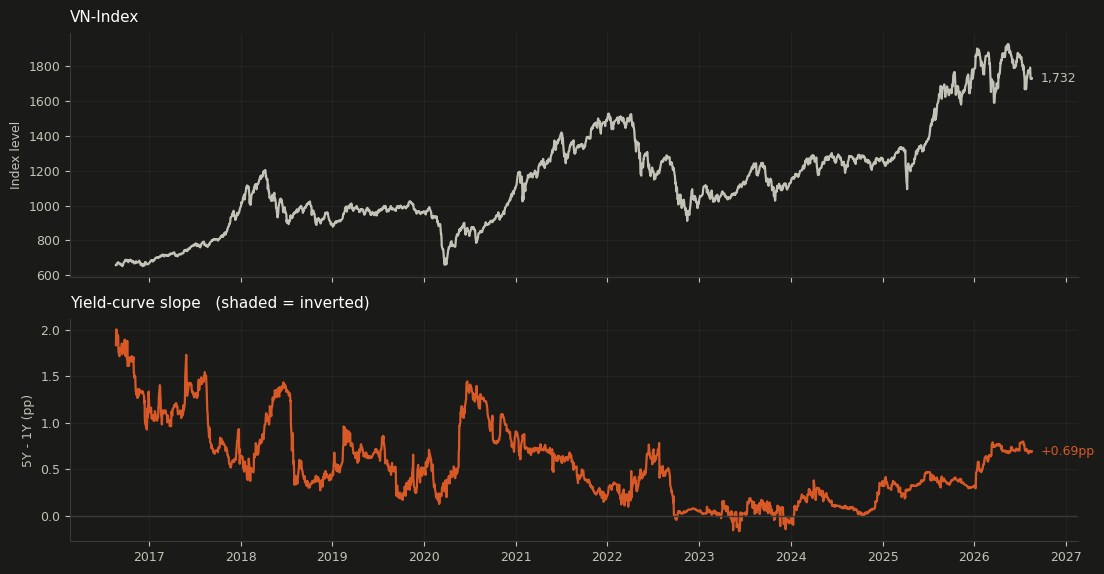

In [49]:
# VN-Index over the curve slope. Stacked, shared x — inversion (slope < 0) shaded.
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 6.6), sharex=True,
                               gridspec_kw={'height_ratios': [1.1, 1]})
fig.patch.set_facecolor(SURFACE)
for ax in (ax1, ax2):
    ax.set_facecolor(SURFACE)

ax1.plot(px.index, px[BENCHMARK], color=BENCH_C, linewidth=1.6)
style_axes(ax1, 'Index level', 'VN-Index')
ax1.annotate(f'{px[BENCHMARK].iloc[-1]:,.0f}', xy=(px.index[-1], px[BENCHMARK].iloc[-1]),
             xytext=(6, 0), textcoords='offset points', color=BENCH_C, fontsize=9, va='center')

sl = slope.reindex(px.index)
ax2.plot(sl.index, sl.values, color=COLORS[CURVE_LONG], linewidth=1.6)
ax2.axhline(0, color=GRID, linewidth=1)
ax2.fill_between(sl.index, sl.values, 0, where=(sl.values < 0),
                 color='#d95926', alpha=0.35, linewidth=0)
style_axes(ax2, '5Y - 1Y (pp)', 'Yield-curve slope   (shaded = inverted)')
ax2.annotate(f'{sl.iloc[-1]:+.2f}pp', xy=(sl.index[-1], sl.iloc[-1]),
             xytext=(6, 0), textcoords='offset points',
             color=COLORS[CURVE_LONG], fontsize=9, va='center')
ax2.xaxis.set_major_locator(mdates.YearLocator())
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
fig.subplots_adjust(right=0.90, hspace=0.18)
plt.show()

In [50]:
# Predictive: forward index return vs (a) the slope LEVEL as a state, and
# (b) trailing slope CHANGE (steepening momentum). HAC/Newey-West, maxlags=h.
log_px  = np.log(px[BENCHMARK])
SLOPE_K = [5, 21, 63]        # trailing slope-change windows
rows = []
for h in FWD_H:
    fwd = log_px.shift(-h) - log_px
    d = pd.concat([fwd.rename('y'), slope.reindex(px.index).rename('x')], axis=1).dropna()
    fit = sm.OLS(d['y'], sm.add_constant(d['x'])).fit(cov_type='HAC', cov_kwds={'maxlags': h})
    rows.append({'signal': 'slope level', 'k': '-', 'fwd h': h,
                 'beta (ret per 1pp)': round(fit.params.iloc[1], 4),
                 't (HAC)': round(fit.tvalues.iloc[1], 2),
                 'p (HAC)': round(fit.pvalues.iloc[1], 3), 'n': len(d)})
    for k in SLOPE_K:
        drv = slope.diff(k).reindex(px.index)
        d = pd.concat([fwd.rename('y'), drv.rename('x')], axis=1).dropna()
        if len(d) < 30:
            continue
        fit = sm.OLS(d['y'], sm.add_constant(d['x'])).fit(cov_type='HAC', cov_kwds={'maxlags': h})
        rows.append({'signal': f'delta-slope k={k}', 'k': k, 'fwd h': h,
                     'beta (ret per 1pp)': round(fit.params.iloc[1], 4),
                     't (HAC)': round(fit.tvalues.iloc[1], 2),
                     'p (HAC)': round(fit.pvalues.iloc[1], 3), 'n': len(d)})
curve_pred = pd.DataFrame(rows)
curve_pred['flag'] = np.where(curve_pred['t (HAC)'].abs() > 2, 'ok', '.')
any_curve = bool((curve_pred['t (HAC)'].abs() > 2).any())
print('Forward VNINDEX return vs yield-curve slope   (HAC, maxlags=h)\n')
print(curve_pred.to_string(index=False))
print(f"\n-> {'at least one (signal,h) cell has |t(HAC)|>2 - inspect neighbours before believing it' if any_curve else 'no cell reaches |t(HAC)|>2 - no predictive slope signal'}.")

Forward VNINDEX return vs yield-curve slope   (HAC, maxlags=h)

          signal  k  fwd h  beta (ret per 1pp)  t (HAC)  p (HAC)    n flag
     slope level  -      1              0.0004     0.75    0.451 2537    .
 delta-slope k=5  5      1             -0.0025    -1.04    0.300 2532    .
delta-slope k=21 21      1             -0.0002    -0.19    0.850 2516    .
delta-slope k=63 63      1             -0.0009    -1.10    0.272 2474    .
     slope level  -      5              0.0021     0.87    0.385 2533    .
 delta-slope k=5  5      5             -0.0048    -0.50    0.617 2528    .
delta-slope k=21 21      5              0.0014     0.24    0.812 2512    .
delta-slope k=63 63      5             -0.0039    -1.08    0.279 2470    .
     slope level  -     10              0.0043     0.94    0.348 2528    .
 delta-slope k=5  5     10             -0.0067    -0.37    0.713 2523    .
delta-slope k=21 21     10              0.0043     0.35    0.728 2507    .
delta-slope k=63 63     10          

### 7b. Where's the edge? — state-conditional forward stats

The §7 regression came back flat, but that only rules out a *linear* slope→return
line. An edge is usually a **bucket**: a curve state where forward risk-adjusted
returns stand apart, even if the average slope carries no signal. So instead of a
predictor, split the days by curve state and read the forward return distribution
per bucket — an edge is a state whose forward **Sharpe / drawdown** clearly
differs from the others, ideally monotone across terciles and not just one thin
cell. Next-day returns are used for the Sharpe/hit columns (non-overlapping, so
each observation is independent and the annualised numbers are honest); a 21-day
forward realised-vol column is carried alongside because that is where the yield
signal lived in the regime notebook.

In [51]:
# Forward windows on the index. Next-day return for the honest (independent)
# Sharpe/hit stats; 21-day forward realised vol for the risk read.
H       = 21
r1      = np.log(px[BENCHMARK]).diff()
fwd1    = r1.shift(-1)                                   # t -> t+1 (non-overlapping)
r_np    = r1.to_numpy()
fwd_vol = pd.Series([r_np[i+1:i+1+H].std() if i+1+H <= len(r_np) else np.nan
                     for i in range(len(r_np))], index=r1.index)

def edge_table(state: pd.Series, order: list) -> pd.DataFrame:
    rows = []
    for s in order:
        m = (state == s) & fwd1.notna()
        rr, vv = fwd1[m], fwd_vol[m]
        if m.sum() < 30:
            continue
        eq = rr.cumsum(); dd = (eq - eq.cummax()).min()
        rows.append({
            'state': s, 'days': int(m.sum()), 'share': f'{m.mean():.0%}',
            'ann.ret': round(rr.mean() * 252 * 100, 1),
            'ann.vol': round(rr.std() * np.sqrt(252) * 100, 1),
            'Sharpe':  round(rr.mean() / rr.std() * np.sqrt(252), 2),
            'hit':     f'{(rr > 0).mean():.0%}',
            'maxDD':   round(dd * 100, 1),
            'fwd21 vol': round(vv.mean() * np.sqrt(252) * 100, 1),
        })
    return pd.DataFrame(rows).set_index('state')

# ── State A: slope LEVEL terciles (flat/inverted -> mid -> steep) ────────────
q = slope.quantile([1/3, 2/3])
lvl_state = pd.Series(
    np.where(slope <= q.iloc[0], 'flat/inverted',
             np.where(slope >= q.iloc[1], 'steep', 'mid')),
    index=slope.index).reindex(fwd1.index)
print(f'slope-level terciles  (cuts at {q.iloc[0]:+.2f} / {q.iloc[1]:+.2f} pp)')
lvl_tbl = edge_table(lvl_state, ['flat/inverted', 'mid', 'steep'])
print(lvl_tbl.to_string(), '\n')

# ── State B: slope MOMENTUM — steepening vs flattening over 21 days ──────────
ds = slope.diff(21).reindex(fwd1.index)
mom_state = pd.Series(np.where(ds > 0, 'steepening', 'flattening'), index=fwd1.index)
print('slope momentum  (21-day change in 5Y-1Y)')
mom_tbl = edge_table(mom_state, ['flattening', 'steepening'])
print(mom_tbl.to_string(), '\n')

# ── Baseline + where the spread is widest ───────────────────────────────────
base_sharpe = round(fwd1.mean() / fwd1.std() * np.sqrt(252), 2)
print(f'buy & hold baseline Sharpe: {base_sharpe}')
for name, tbl in [('level', lvl_tbl), ('momentum', mom_tbl)]:
    if tbl.empty:
        continue
    best, worst = tbl['Sharpe'].idxmax(), tbl['Sharpe'].idxmin()
    print(f'  {name}: best \'{best}\' Sharpe {tbl.loc[best, "Sharpe"]} vs '
          f'worst \'{worst}\' {tbl.loc[worst, "Sharpe"]}  '
          f'(spread {tbl["Sharpe"].max() - tbl["Sharpe"].min():.2f})')

slope-level terciles  (cuts at +0.32 / +0.68 pp)
               days share  ann.ret  ann.vol  Sharpe  hit  maxDD  fwd21 vol
state                                                                     
flat/inverted   851   34%     -5.7     19.4   -0.29  54%  -61.9       17.1
mid             837   33%     20.5     19.2    1.07  57%  -23.8       16.8
steep           849   33%     14.3     17.5    0.82  56%  -32.6       14.7 

slope momentum  (21-day change in 5Y-1Y)
            days share  ann.ret  ann.vol  Sharpe  hit  maxDD  fwd21 vol
state                                                                  
flattening  1301   51%      9.3     17.9    0.52  57%  -46.4       15.8
steepening  1236   49%      9.9     19.6    0.51  55%  -36.7       16.7 

buy & hold baseline Sharpe: 0.51
  level: best 'mid' Sharpe 1.07 vs worst 'flat/inverted' -0.29  (spread 1.36)
  momentum: best 'flattening' Sharpe 0.52 vs worst 'steepening' 0.51  (spread 0.01)


## 8. Verdict

In [52]:
band = 1.96 / np.sqrt(len(ret))
summary = []
for t in TENORS:
    peak_d = xc[t].abs().idxmax()
    peak_w = xc_w[t].abs().idxmax()
    sub    = pred[pred['tenor'] == LABEL[t]]
    top    = sub.loc[sub['t (HAC)'].abs().idxmax()]
    summary.append({
        'tenor': LABEL[t],
        'daily r (lag 0)': round(ret[BENCHMARK].corr(ret[t]), 4),
        'signif': '✓' if abs(ret[BENCHMARK].corr(ret[t])) > band else '·',
        'weekly r (lag 0)': round(xc_w[t].loc[0], 4),
        'monthly r': horizon_tbl.loc['monthly', LABEL[t]] if 'monthly' in horizon_tbl.index else np.nan,
        'best daily lag': int(peak_d),
        'best weekly lag': int(peak_w),
        'rolling r sign flips': int((np.sign(roll[t]).replace(0, np.nan).ffill()
                                    .diff().abs() > 0).sum()),
        'strongest predictor': f"k={int(top['Δyield window (k)'])}, h={int(top['fwd horizon (h)'])}",
        'its t (HAC)': top['t (HAC)'],
    })
verdict = pd.DataFrame(summary).set_index('tenor')

print(f'Sample: {len(ret)} trading days, {px.index[0].date()} -> {px.index[-1].date()}')
print(f'Single-test |r| threshold: {band:.4f}\n')
print(verdict.to_string(), '\n')

sd = {LABEL[t]: ret[BENCHMARK].corr(ret[t]) for t in TENORS}
strongest = max(sd, key=lambda k: abs(sd[k]))
any_pred  = (pred['t (HAC)'].abs() > 2).any()
print(f"• Strongest same-day link: {strongest} at r = {sd[strongest]:+.3f} "
      f"({'above' if abs(sd[strongest]) > band else 'below'} the significance band).")
print(f"• Sign of the same-day relationship: "
      f"{'negative — yields up, index down' if sd[strongest] < 0 else 'positive — they rise together'}.")
if {'daily', 'monthly'}.issubset(horizon_tbl.index):
    d, m = horizon_tbl.loc['daily'], horizon_tbl.loc['monthly']
    worst = max(TENORS, key=lambda t: abs(m[LABEL[t]]))
    print(f"• Horizon matters more than lag: {LABEL[worst]} goes from r = {d[LABEL[worst]]:+.3f} "
          f"daily to {m[LABEL[worst]]:+.3f} monthly — a slow relationship that daily noise buries.")
w_peaks = [int(xc_w[t].abs().idxmax()) for t in TENORS]
d_peaks = [int(xc[t].abs().idxmax()) for t in TENORS]
if all(p == 0 for p in w_peaks):
    print(f"• Lead–lag: at weekly frequency every tenor peaks at lag 0 — no evidence either "
          f"side leads. The daily peaks ({d_peaks} days) are noise: each lag shares almost "
          f"its whole sample with its neighbours, and no contiguous hump forms off zero.")
else:
    print(f"• Lead–lag: weekly peaks at {w_peaks} weeks, daily at {d_peaks} days "
          f"({'yields lead' if np.mean(w_peaks) > 0 else 'index leads'} on the weekly scan).")
best_curve = curve_pred.loc[curve_pred["t (HAC)"].abs().idxmax()]
print(f"• Yield curve (5Y-1Y): same-day index vs delta-slope r={r_p:+.3f} "
      f"({'signif' if abs(r_p) > 1.96/np.sqrt(len(ret)) else 'n.s.'}); "
      f"strongest forward signal {best_curve['signal']} at h={int(best_curve['fwd h'])} "
      f"t(HAC)={best_curve['t (HAC)']:+.2f} "
      f"({'worth a look' if abs(best_curve['t (HAC)']) > 2 else 'below |t|=2'}); "
      f"curve inverted on {(slope < 0).mean():.0%} of days.")
print(f"• Predictive power: {'at least one (k,h) cell has |t(HAC)| > 2 — inspect its neighbours before believing it' if any_pred else 'no (k,h) cell reaches |t(HAC)| > 2 — no tradeable lead found'}.")
print("\nCaveat: 121 lags x 3 tenors x 12 predictive cells were scanned. Treat any "
      "single flagged cell as a hypothesis to test out-of-sample, not a finding.")

Sample: 2537 trading days, 2016-08-22 -> 2026-08-19
Single-test |r| threshold: 0.0389

       daily r (lag 0) signif  weekly r (lag 0)  monthly r  best daily lag  best weekly lag  rolling r sign flips strongest predictor  its t (HAC)
tenor                                                                                                                                             
1Y             -0.0652      ✓           -0.1373     -0.300               0                0                    61            k=1, h=1        -2.54
5Y             -0.0725      ✓           -0.2139     -0.383               0                0                    37            k=1, h=1        -2.07
10Y            -0.0809      ✓           -0.2459     -0.395              -1                0                    46            k=1, h=1        -2.52 

• Strongest same-day link: 10Y at r = -0.081 (above the significance band).
• Sign of the same-day relationship: negative — yields up, index down.
• Horizon matters more than l